In [1]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Dim reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap # <== NOT a scikit-learn library, but follows the interface, installed using umap-learn name

import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

# Unsupervised models in scikit-learn: clustering and dimentionality reduction

An earlier lecturer presented the scikit-learn library and its overall design. In learning that design, the students were introduced to supervised learning. Like the earlier lecture, the goal of this lecture is not to teach students all details of clustering techniques. This lecture remains an introduction to the API used for relevant tasks in data science.

## Cluster trades into common categories
Our task is to build a table containing common attributes of all US stocks: volume, closing price, number of transactions, average size of trades, etc. Note that "average/mean size of trades" needs to be calculated from a large file containing all trades done for a day. 

Once we have enrichsed end-of-day data for each stock with mean_size calculation, we will start the process of building clusters.

Note that in a real-world scenario, _lots_ more features could be added as input to the clustering algorithm.

## Feature Engineering
Very similar to an earlier lecture

### Read EOD data

In [37]:
ohlcv_sept_df = pd.read_csv('../../datasets/market_data/ohlcv_2025-sept.csv.zip', parse_dates=["date"])\
                    .sort_values(["ticker", "date"])
ohlcv_sept_df

,ticker,date,open,high,low,close,volume
0,A,2025-09-02,124.879997,125.519997,121.800003,125.209999,2412700
1,A,2025-09-03,124.959999,125.830002,123.720001,125.220001,2497300
2,A,2025-09-04,125.000000,128.830002,123.800003,128.479996,2715400
3,A,2025-09-05,128.720001,131.000000,128.389999,128.750000,1633200
4,A,2025-09-08,127.480003,128.419998,126.279999,128.130005,2136200
...,...,...,...,...,...,...,...
87556,ZYME,2025-09-24,16.440001,16.610001,16.055000,16.299999,521200
87557,ZYME,2025-09-25,16.180000,16.200001,15.810000,16.160000,563200
87558,ZYME,2025-09-26,16.270000,16.660000,16.059999,16.600000,521700
87559,ZYME,2025-09-29,16.860001,17.600000,16.740000,17.230000,555500


### Create features per symbol: volatility, total_return, etc.

In [38]:
ohlcv_sept_df["ret"]        = ohlcv_sept_df.groupby("ticker")["close"].pct_change()     # daily return
ohlcv_sept_df["dollar_vol"] = ohlcv_sept_df["close"] * ohlcv_sept_df["volume"]          # $ traded that day
ohlcv_sept_df["range_pct"]  = (ohlcv_sept_df["high"] - ohlcv_sept_df["low"]) / ohlcv_sept_df["close"]         # intraday range

ohlcv_sept_df

,ticker,date,open,high,low,close,volume,ret,dollar_vol,range_pct
0,A,2025-09-02,124.879997,125.519997,121.800003,125.209999,2412700,NaN,3.020942e+08,0.029710
1,A,2025-09-03,124.959999,125.830002,123.720001,125.220001,2497300,0.000080,3.127119e+08,0.016850
2,A,2025-09-04,125.000000,128.830002,123.800003,128.479996,2715400,0.026034,3.488746e+08,0.039150
3,A,2025-09-05,128.720001,131.000000,128.389999,128.750000,1633200,0.002102,2.102745e+08,0.020272
4,A,2025-09-08,127.480003,128.419998,126.279999,128.130005,2136200,-0.004815,2.737113e+08,0.016702
...,...,...,...,...,...,...,...,...,...,...
87556,ZYME,2025-09-24,16.440001,16.610001,16.055000,16.299999,521200,-0.003668,8.495560e+06,0.034049
87557,ZYME,2025-09-25,16.180000,16.200001,15.810000,16.160000,563200,-0.008589,9.101312e+06,0.024134
87558,ZYME,2025-09-26,16.270000,16.660000,16.059999,16.600000,521700,0.027228,8.660220e+06,0.036145
87559,ZYME,2025-09-29,16.860001,17.600000,16.740000,17.230000,555500,0.037952,9.571265e+06,0.049913


### Calculate market return (needed to calculate "Beta" or correlation w/ market)

In [39]:
beta_s = ohlcv_sept_df.groupby("date")["ret"].mean().rename("mkt")
beta_s

date
2025-09-02         NaN
2025-09-03    0.000205
2025-09-04    0.008583
2025-09-05    0.005212
2025-09-08    0.001482
2025-09-09    0.000481
2025-09-10   -0.001143
2025-09-11    0.018585
2025-09-12   -0.007150
2025-09-15    0.001974
2025-09-16    0.021788
2025-09-17   -0.000895
2025-09-18    0.017452
2025-09-19   -0.003098
2025-09-22    0.018168
2025-09-23   -0.002015
2025-09-24    0.011380
2025-09-25   -0.006753
2025-09-26    0.006795
2025-09-29    0.012176
2025-09-30    0.003786
Name: mkt, dtype: float64

### Add beta to the dataframe

In [40]:
ohlcv_sept_df = ohlcv_sept_df.join(beta_s, on='date')
ohlcv_sept_df

,ticker,date,open,high,low,close,volume,ret,dollar_vol,range_pct,mkt
0,A,2025-09-02,124.879997,125.519997,121.800003,125.209999,2412700,NaN,3.020942e+08,0.029710,NaN
1,A,2025-09-03,124.959999,125.830002,123.720001,125.220001,2497300,0.000080,3.127119e+08,0.016850,0.000205
2,A,2025-09-04,125.000000,128.830002,123.800003,128.479996,2715400,0.026034,3.488746e+08,0.039150,0.008583
3,A,2025-09-05,128.720001,131.000000,128.389999,128.750000,1633200,0.002102,2.102745e+08,0.020272,0.005212
4,A,2025-09-08,127.480003,128.419998,126.279999,128.130005,2136200,-0.004815,2.737113e+08,0.016702,0.001482
...,...,...,...,...,...,...,...,...,...,...,...
87556,ZYME,2025-09-24,16.440001,16.610001,16.055000,16.299999,521200,-0.003668,8.495560e+06,0.034049,0.011380
87557,ZYME,2025-09-25,16.180000,16.200001,15.810000,16.160000,563200,-0.008589,9.101312e+06,0.024134,-0.006753
87558,ZYME,2025-09-26,16.270000,16.660000,16.059999,16.600000,521700,0.027228,8.660220e+06,0.036145,0.006795
87559,ZYME,2025-09-29,16.860001,17.600000,16.740000,17.230000,555500,0.037952,9.571265e+06,0.049913,0.012176


### Calculate aggregate features per symbol

In [41]:
ohlcv_groupby_df = ohlcv_sept_df.groupby('ticker')

In [44]:
features_df = pd.DataFrame({
    "n_days":         ohlcv_groupby_df.size(),
    "vol":            ohlcv_groupby_df["ret"].std(),                             # daily volatility
    "total_ret":      ohlcv_groupby_df["close"].last() / ohlcv_groupby_df["close"].first() - 1, # month return (momentum)
    "avg_range":      ohlcv_groupby_df["range_pct"].mean(),                      # how wild intraday
    "avg_dollar_vol": ohlcv_groupby_df["dollar_vol"].mean(),                     # liquidity
    "last_price":     ohlcv_groupby_df["close"].last(),                          # price level
    "beta":           ohlcv_groupby_df[["ret", "mkt"]]
                        .apply(lambda x: x["ret"].cov(x["mkt"]) / x["mkt"].var()),
})

# Tickers with <2 usable return days make cov() divide by zero -> NaN beta.

features_df

/opt/anaconda3/envs/finmat/lib/python3.10/site-packages/pandas/core/nanops.py:1675: RuntimeWarning: Degrees of freedom <= 0 for slice
  return np.cov(a, b, ddof=ddof)[0, 1]
/opt/anaconda3/envs/finmat/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/envs/finmat/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,n_days,vol,total_ret,avg_range,avg_dollar_vol,last_price,beta
ticker,,,,,,,
A,21,0.016499,0.025078,0.021321,2.241696e+08,128.350006,0.979249
AA,21,0.021964,0.063025,0.035876,2.099470e+08,32.889999,0.634092
AADR,21,0.005967,0.058307,0.009068,1.847503e+05,86.760002,-0.000706
AAL,21,0.016717,-0.160568,0.033501,1.127458e+09,11.240000,0.435666
AAME,21,0.031435,-0.135542,0.066371,1.388598e+05,2.870000,0.763359
...,...,...,...,...,...,...,...
ZTO,21,0.013706,0.074426,0.020192,3.324154e+07,19.200001,0.208257
ZTR,21,0.005774,0.027070,0.009783,1.232547e+06,6.450000,-0.014700
ZTS,21,0.010269,-0.042909,0.020639,4.126896e+08,146.320007,0.494506


### Read sectors

In [7]:
sectors_df = pd.read_csv('../../datasets/market_data/sectors.csv.zip')\
            .rename(columns={"company name": "company", "market cap": "market_cap"})\
             [["ticker", "company", "sector", "market_cap"]]\
             .dropna(subset=["sector"])
sectors_df

,ticker,company,sector,market_cap
0,A,Agilent Technologies Inc.,Healthcare,2.421807e+10
1,AA,Alcoa Corporation,Basic Materials,5.374967e+09
2,AABA,Altaba Inc.,Financial Services,4.122368e+10
3,AAC,AAC Holdings Inc.,Healthcare,6.372010e+07
5,AAL,American Airlines Group Inc.,Industrials,1.694019e+10
...,...,...,...,...
6363,ZTS,Zoetis Inc. Class A,Healthcare,4.205627e+10
6364,ZUMZ,Zumiez Inc.,Consumer Cyclical,6.150368e+08
6365,ZUO,Zuora Inc. Class A,Technology,2.304595e+09
6366,ZYME,Zymeworks Inc.,Healthcare,5.042878e+08


### Combine features table with sectors

In [45]:
features_df = features_df.join(sectors_df.set_index("ticker")[["company", "sector", "market_cap"]], how="left")


,n_days,vol,total_ret,avg_range,avg_dollar_vol,last_price,beta,company,sector,market_cap
ticker,,,,,,,,,,
A,21,0.016499,0.025078,0.021321,2.241696e+08,128.350006,0.979249,Agilent Technologies Inc.,Healthcare,2.421807e+10
AA,21,0.021964,0.063025,0.035876,2.099470e+08,32.889999,0.634092,Alcoa Corporation,Basic Materials,5.374967e+09
AADR,21,0.005967,0.058307,0.009068,1.847503e+05,86.760002,-0.000706,NaN,NaN,NaN
AAL,21,0.016717,-0.160568,0.033501,1.127458e+09,11.240000,0.435666,American Airlines Group Inc.,Industrials,1.694019e+10
AAME,21,0.031435,-0.135542,0.066371,1.388598e+05,2.870000,0.763359,Atlantic American Corporation,Financial Services,5.655808e+07
...,...,...,...,...,...,...,...,...,...,...
ZTO,21,0.013706,0.074426,0.020192,3.324154e+07,19.200001,0.208257,ZTO Express (Cayman) Inc. American Depositary ...,Industrials,1.385015e+10
ZTR,21,0.005774,0.027070,0.009783,1.232547e+06,6.450000,-0.014700,Virtus Global Dividend & Income Fund Inc.,Financial Services,2.589764e+08
ZTS,21,0.010269,-0.042909,0.020639,4.126896e+08,146.320007,0.494506,Zoetis Inc. Class A,Healthcare,4.205627e+10


### Drop rows with missing values

In [47]:
features_df = features_df[features_df.n_days >= 15].dropna(
    subset=["vol", "beta", "total_ret", "avg_range", "avg_dollar_vol", "last_price", "market_cap"])


,n_days,vol,total_ret,avg_range,avg_dollar_vol,last_price,beta,company,sector,market_cap
ticker,,,,,,,,,,
A,21,0.016499,0.025078,0.021321,2.241696e+08,128.350006,0.979249,Agilent Technologies Inc.,Healthcare,2.421807e+10
AA,21,0.021964,0.063025,0.035876,2.099470e+08,32.889999,0.634092,Alcoa Corporation,Basic Materials,5.374967e+09
AAL,21,0.016717,-0.160568,0.033501,1.127458e+09,11.240000,0.435666,American Airlines Group Inc.,Industrials,1.694019e+10
AAME,21,0.031435,-0.135542,0.066371,1.388598e+05,2.870000,0.763359,Atlantic American Corporation,Financial Services,5.655808e+07
AAOI,21,0.052356,0.110493,0.069956,1.309677e+08,25.930000,-0.860932,Applied Optoelectronics Inc.,Technology,3.522182e+08
...,...,...,...,...,...,...,...,...,...,...
ZTO,21,0.013706,0.074426,0.020192,3.324154e+07,19.200001,0.208257,ZTO Express (Cayman) Inc. American Depositary ...,Industrials,1.385015e+10
ZTR,21,0.005774,0.027070,0.009783,1.232547e+06,6.450000,-0.014700,Virtus Global Dividend & Income Fund Inc.,Financial Services,2.589764e+08
ZTS,21,0.010269,-0.042909,0.020639,4.126896e+08,146.320007,0.494506,Zoetis Inc. Class A,Healthcare,4.205627e+10


In [ ]:
features_df

## Build a clustering model

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


### Build a naive clustering model (same as an earlier lecture)

In [51]:
%%time
RAW_FEATURES = ["vol", "total_ret", "avg_range", "avg_dollar_vol",
                "last_price", "market_cap", "beta"]

naive_model = Pipeline([
    ("scale",  StandardScaler()),
    ("kmeans", KMeans(n_clusters=5, random_state=42, n_init="auto")),
])
features_df["naive_cluster"] = naive_model.fit_predict(features_df[RAW_FEATURES])

CPU times: user 22.8 ms, sys: 51.4 ms, total: 74.3 ms
Wall time: 70.3 ms


Notice the method `fit_predict` is a combination of `fit` and `predict` methods we saw in the supervised learning lecture. We are telling KMeans to _learn the distribution_ and assign the same data to the learned clusters as well.

In [54]:
naive_model.named_steps['kmeans']

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [55]:
distances = naive_model.fit_transform(features_df[RAW_FEATURES])
pd.DataFrame(distances, columns=[f"dist_to_cluster_{i}" for i in range(naive_model.named_steps['kmeans'].n_clusters)],
             index=features_df.index).head(3).round(2)

,dist_to_cluster_0,dist_to_cluster_1,dist_to_cluster_2,dist_to_cluster_3,dist_to_cluster_4
ticker,,,,,
A,0.36,64.43,39.95,19.88,27.49
AA,0.17,64.42,39.86,20.16,27.46
AAL,1.10,64.44,40.40,19.31,27.48


Notice that this time we used the method `fit_transform`. Now we are asking kmeans to learn the distributions using the `fit` function and to `transform` the same data into distances

### What does the performance look like?

#### The clusters are extremely sekewed!

In [56]:
features_df["naive_cluster"].value_counts()

naive_cluster
0    3349
3       8
4       4
2       2
1       1
Name: count, dtype: int64

Clusters are fairly skewed. _You should sense trouble, this is NOT good news_

#### The silhouette score is TOO perfect!

In [57]:
from sklearn.metrics import silhouette_score

In [60]:
zscores = StandardScaler().fit_transform(features_df[RAW_FEATURES])  # the space KMeans saw
pd.DataFrame(zscores, columns = RAW_FEATURES)

,vol,total_ret,avg_range,avg_dollar_vol,last_price,market_cap,beta
0,-0.069534,-0.014174,-0.067186,0.071802,-0.013007,0.310989,-0.011109
1,-0.053958,0.081615,-0.028062,0.057968,-0.020349,-0.127481,-0.030339
2,-0.068911,-0.482792,-0.034446,0.950391,-0.022014,0.141636,-0.041395
3,-0.026965,-0.419621,0.053908,-0.146103,-0.022658,-0.251238,-0.023137
4,0.032664,0.201434,0.063543,-0.018851,-0.020884,-0.244358,-0.113637
...,...,...,...,...,...,...,...
3359,-0.077493,0.110394,-0.070220,-0.113905,-0.021402,0.069732,-0.054065
3360,-0.100100,-0.009146,-0.098199,-0.145039,-0.022382,-0.246528,-0.066488
3361,-0.087289,-0.185792,-0.069018,0.255167,-0.011625,0.726076,-0.038117
3362,-0.000012,0.252977,-0.022154,-0.140266,-0.021370,-0.238243,-0.006777


Silhouette score

In [63]:
silhouette_score(zscores, features_df['naive_cluster'])

0.9626824443057426

Silhouette score is a very common measure of the quality of a cluster (see Wikipedia article for mathematical definition: https://en.wikipedia.org/wiki/Silhouette_(clustering)).

This measure indicates **how close a point is to its own cluster vs other clusters**. This is sometimes called the cohesion/separation score. The scores range between -1 and 1. This measure breaks down when almost all the points are in the same cluster (as is the case in our model)

#### PCA further shows that the data is not evernly distributed
**NOTE** We are using PCA only to show the variance of data across two of the most consequential dimensions. If you wanted to visualize clusters in 2 dimensional space, you would use TSNE (built into Scikit-learn) or UMAP (more modern). They don't work for our purpose because they discard global informaiton in favor of local information. 

In [85]:
from sklearn.decomposition import PCA

In [102]:
pca_raw = PCA(n_components=2).fit_transform(zscores)
pd.concat([
    pd.DataFrame(pca_raw, columns=['x', 'y']).reset_index(), 
    features_df.naive_cluster.reset_index()
    ], axis=1).hvplot.scatter('x', 'y', c='naive_cluster', cmap='viridis')

:Scatter   [x]   (y,naive_cluster)

Reminder that almost all of the points are in cluster zero

In [95]:
features_df.naive_cluster.value_counts()

naive_cluster
0    3349
3       8
4       4
2       2
1       1
Name: count, dtype: int64

### Why is the performance so bad?

In [104]:
from pandas.plotting import scatter_matrix

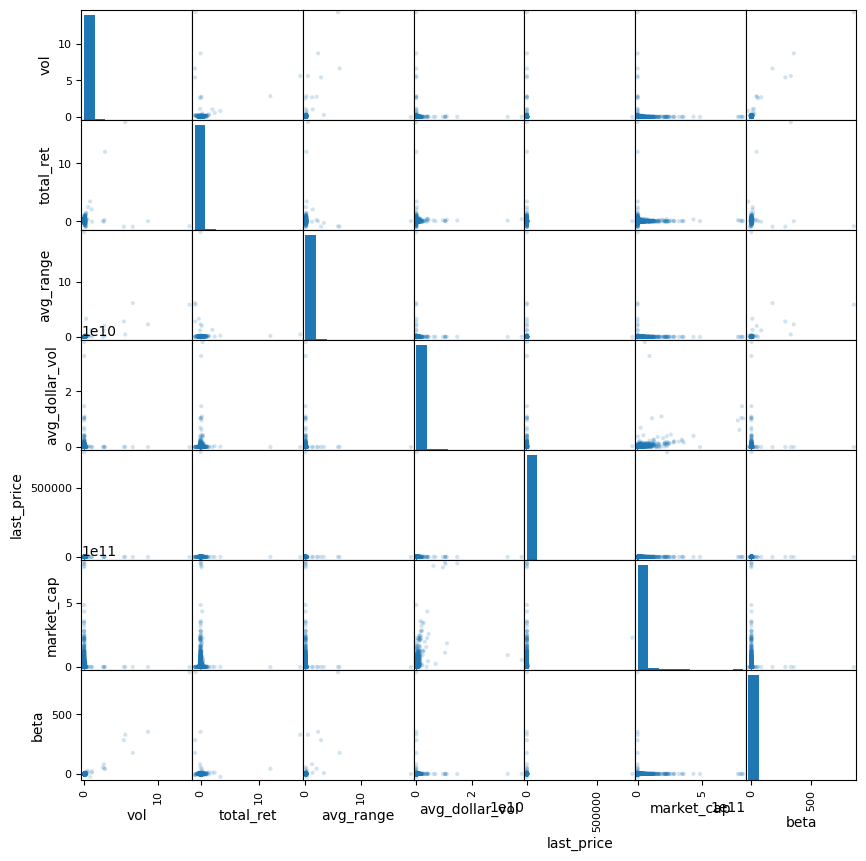

In [110]:
scatter_matrix(features_df[RAW_FEATURES], alpha=0.2, figsize=(10, 10));

/opt/anaconda3/envs/finmat/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


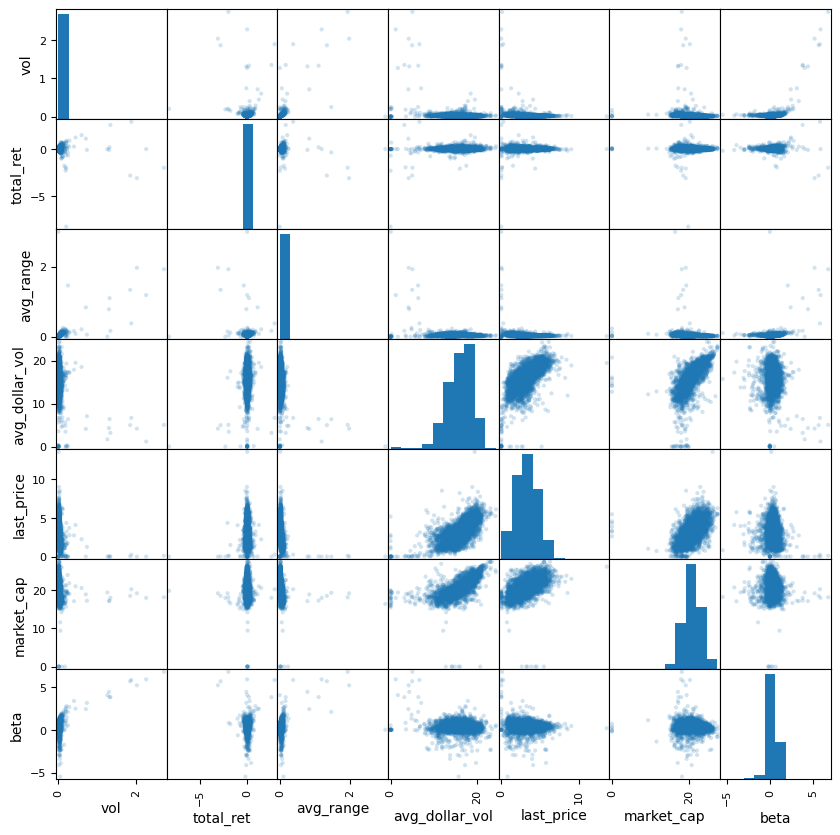

In [114]:
scatter_matrix(np.log(features_df[RAW_FEATURES]+1), alpha=0.2, figsize=(10, 10));

#### Did you notice? In the source table, _everything_ iis super skewed!

<Axes: ylabel='Frequency'>

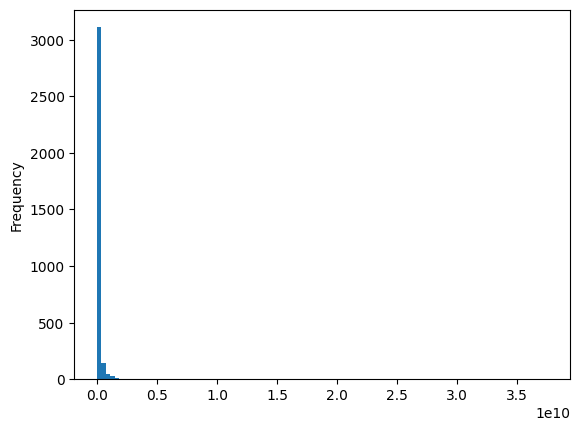

In [121]:
features_df['avg_dollar_vol'].plot.hist(bins=100)

<Axes: ylabel='Frequency'>

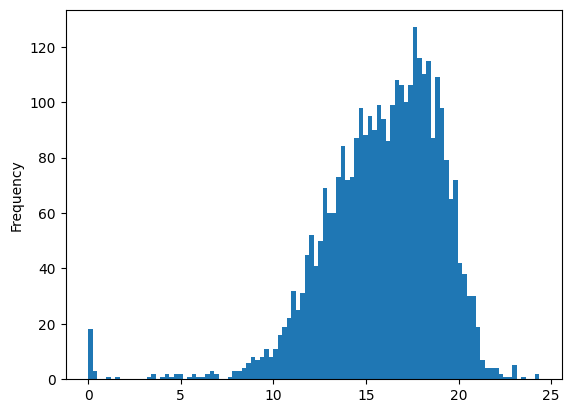

In [119]:
np.log(features_df['avg_dollar_vol'] + 1).plot.hist(bins=100)

#### The values have completely different orders of magnitude

In [125]:
features_df[RAW_FEATURES].describe().transpose()[['min', 'max']]

,min,max
vol,0.000000,1.427469e+01
total_ret,-0.999737,1.712500e+01
avg_range,0.000000,1.904762e+01
avg_dollar_vol,0.000000,3.757129e+10
last_price,0.000010,7.542000e+05
market_cap,0.000000,8.163235e+11
beta,-25.303501,8.516699e+02


#### There is auto-correlation

In [135]:
features_df[RAW_FEATURES].corr().style.background_gradient(cmap='coolwarm').format(precision=2)

,vol,total_ret,avg_range,avg_dollar_vol,last_price,market_cap,beta
vol,1.00,0.24,0.39,-0.01,-0.00,-0.02,0.96
total_ret,0.24,1.00,-0.00,0.02,-0.00,-0.00,0.21
avg_range,0.39,-0.00,1.00,-0.01,-0.00,-0.02,0.35
avg_dollar_vol,-0.01,0.02,-0.01,1.00,0.00,0.45,-0.01
last_price,-0.00,-0.00,-0.00,0.00,1.00,0.09,-0.00
market_cap,-0.02,-0.00,-0.02,0.45,0.09,1.00,-0.01
beta,0.96,0.21,0.35,-0.01,-0.00,-0.01,1.00


Notice that `beta` and `vol` are very similar. `avg_dollar_vol` and `market_cap` have unexpectedly high siimilarity

### Let's resolve these issues

In [236]:
def cluster_and_viz(df, cluster_size):
    # Create a copy so the label column can be added
    draw_df = df.copy()

    # Cluster the dataframe
    draw_df['cluster'] = KMeans(n_clusters=cluster_size, random_state=42, n_init="auto").fit_predict(df)
    #draw_df['cluster'] = draw_df['cluster'].astype('category')
    silhouette_number = silhouette_score(df, draw_df.cluster)

    # Normalize dataframe to feed into PCA
    zscores = StandardScaler().fit_transform(df)  # the space KMeans saw

    # Reduce dimensions via PCA
    pca_raw = PCA(n_components=2).fit_transform(zscores)

    # Convert PCA to dataframe
    pca_df = pd.DataFrame(pca_raw, columns=['x', 'y'], index=df.index)

    # Combine PCA with labels
    combined_df = pd.concat([pca_df, draw_df.cluster], axis=1)
    
    return silhouette_number, draw_df.cluster.value_counts(), combined_df.hvplot.scatter('x', 'y', c='cluster', cmap='viridis')

#### Clean the data and remove outliers
Although...sometimes outliers are the points you want to track!

In [237]:
features_df.shape

(3364, 11)

In [238]:
clean_df = features_df[
    (features_df.last_price >= 1) &         # No silly stocks (back in the day these would be Bulletin Board and Pink Sheet stocks)
    (features_df.avg_dollar_vol >= 1e5) &   # Not super thinly tarded stocks
    (features_df.vol < 0.5) &              # Not to crazy volatility
    (features_df.market_cap > 0)           # Sanity check
    ]

clean_df.shape

(3098, 11)

In [239]:
silhouette_number, clusters_count, chart = cluster_and_viz(clean_df[RAW_FEATURES], 5)
silhouette_number

0.8700695944678198

In [240]:
clusters_count

cluster
0    2868
3     186
4      33
1       6
2       5
Name: count, dtype: int64

In [241]:
chart

:Scatter   [x]   (y,cluster)

#### Let's log transform and scale relevant columns

In [261]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [262]:
LOG_FEATURES = ["avg_dollar_vol", "last_price"]      # multiplicative -> log
LIN_FEATURES = ["vol", "total_ret", "beta"]          # already tame -> scale only
MODEL_FEATURES = LOG_FEATURES + LIN_FEATURES


In [263]:
transformed = ColumnTransformer([
    ("log", Pipeline([("log", FunctionTransformer(np.log10)),
                      ("scale", StandardScaler())]), LOG_FEATURES),
    ("lin", StandardScaler(), LIN_FEATURES),
]).fit_transform(clean_df[MODEL_FEATURES])

# Unfortunately ColumnTransformer returns a numpy array, not a DataFrae (strange, I know)
transformed_df = pd.DataFrame(transformed, columns = MODEL_FEATURES)

In [264]:
silhouette_number, clusters_count, chart = cluster_and_viz(transformed_df, 5)
silhouette_number

0.21325015604152345

In [265]:
clusters_count

cluster
1    1012
3     917
0     904
4     253
2      12
Name: count, dtype: int64

In [266]:
chart

:Scatter   [x]   (y,cluster)

The distirbution of values across clusters is MUCH more reasonable, even if the Silhouette score has dropped (the "great" score form earlier was not a true reflection of the quality of clusters anyway).

#### Now let's pick the _number_ of clusters correctly
The number '5' was just an arbitrary choice

In [249]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [311]:
%%time
kmeans_params = list()
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(transformed_df)
    kmeans_params.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(transformed_df, km.labels_),
        #"calinski_harabasz": calinski_harabasz_score(transformed_df, km.labels_),
        #"davies_bouldin": davies_bouldin_score(transformed_df, km.labels_),
    })

CPU times: user 1.64 s, sys: 4.48 s, total: 6.12 s
Wall time: 514 ms


In [312]:
kmeans_scores = pd.DataFrame(kmeans_params)#.set_index("k")
kmeans_scores

,k,inertia,silhouette
0,2,14318.919343,0.429322
1,3,11214.436293,0.435287
2,4,9445.325087,0.357350
3,5,8007.203301,0.365549
4,6,7421.752188,0.368554
5,7,6952.161107,0.368425
6,8,6705.677378,0.317734
7,9,6284.283290,0.318356


In [259]:
kmeans_scores.hvplot.line('k', 'inertia')

:Curve   [k]   (inertia)

In [260]:
kmeans_scores.hvplot.line('k', 'silhouette')

:Curve   [k]   (silhouette)

We saw **silhouette score** earlier. Now we also see the **inertia**. Inertia is the sum of squared distances of each point with respect to the center of its cluster. Inertia is most often used as part of the **elbow method.** This method is a heuristic where an "elbow" or a "kin" in the line chart is used to find the idea number of clusters in a k-means cluster.

See https://scikit-learn.org/stable/modules/clustering.html for more details

We had picked the cluster size as 5; 3 would also be reasonable.

### What do these clusters mean?

In [316]:
transformed_df.shape

(3098, 7)

In [269]:
clusters5 = KMeans(n_clusters=5, random_state=42, n_init="auto").fit_predict(transformed_df)

In [270]:
clusters3 = KMeans(n_clusters=3, random_state=42, n_init="auto").fit_predict(transformed_df)

In [271]:
transformed_df['clusters_3'] = clusters3
transformed_df['clusters_5'] = clusters5

Put the symbols back in

In [319]:
transformed_df['symbol'] = clean_df.index

In [320]:
transformed_df.head()

,avg_dollar_vol,last_price,vol,total_ret,beta,clusters_3,clusters_5,symbol
0,1.140991,1.066089,-0.283964,0.030950,0.373903,1,3,A
1,1.113800,0.113516,-0.063889,0.306188,0.063329,1,3,AA
2,1.811079,-0.637640,-0.275166,-1.315572,-0.115217,1,1,AAL
3,-1.923253,-1.592714,0.317495,-1.134057,0.179644,0,0,AAME
4,0.918038,-0.052828,1.159987,0.650478,-1.281903,1,3,AAOI


In [321]:
transformed_long_5_df = transformed_df.melt(id_vars='clusters_5', value_vars=MODEL_FEATURES,
                           var_name='feature', value_name='value')
transformed_long_5_df

,clusters_5,feature,value
0,3,avg_dollar_vol,1.140991
1,3,avg_dollar_vol,1.113800
2,1,avg_dollar_vol,1.811079
3,0,avg_dollar_vol,-1.923253
4,3,avg_dollar_vol,0.918038
...,...,...,...
15485,1,beta,-0.319841
15486,0,beta,-0.520458
15487,3,beta,-0.062272
15488,4,beta,0.443852


In [322]:
# I'm sure there are less ugly ways of doing this - postponed until a future version of this lecture
transformed_long_3_df = transformed_df.melt(id_vars='clusters_3', value_vars=MODEL_FEATURES,
                           var_name='feature', value_name='value')

#### Draw box plots and interpret with your brain

In [323]:
import seaborn as sns

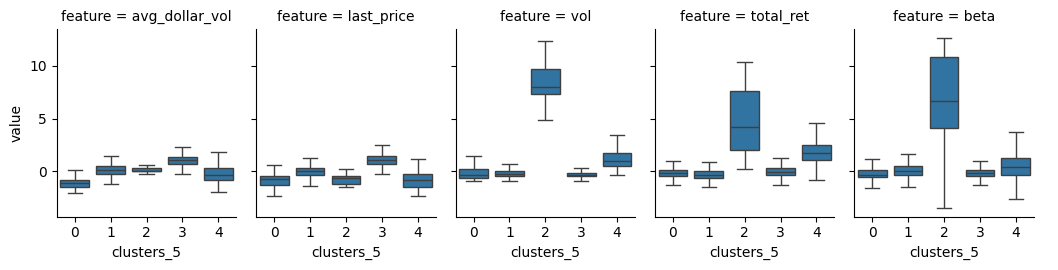

In [324]:
sns.catplot(data=transformed_long_5_df, x='clusters_5', y='value', col='feature', col_wrap=5,
            kind='box', height=2.8, aspect=0.75, showfliers=False)

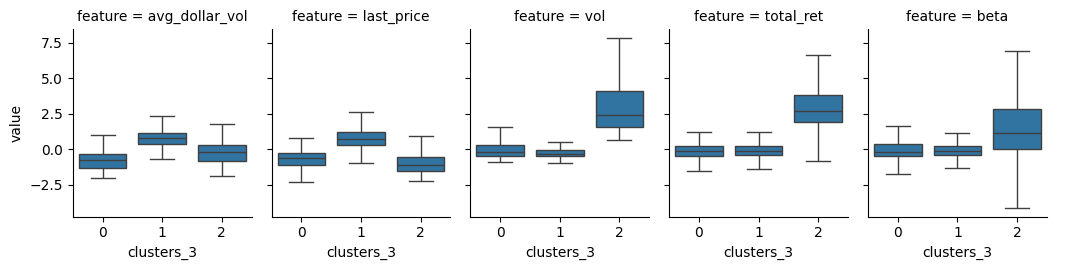

In [309]:
sns.catplot(data=transformed_long_3_df, x='clusters_3', y='value', col='feature', col_wrap=5,
            kind='box', height=2.8, aspect=0.75, showfliers=False)

Swap 'x' and 'col' attributes to see the chart 'the other way around'

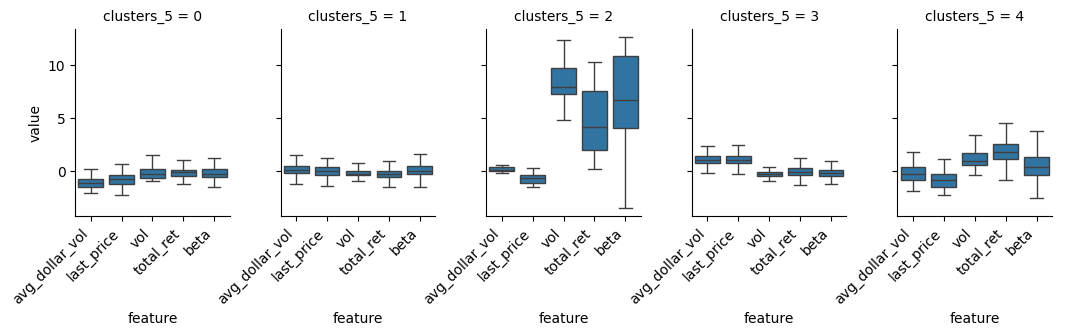

In [331]:
g = sns.catplot(data=transformed_long_5_df, col='clusters_5', y='value', x='feature', col_wrap=5,
            kind='box', height=2.8, aspect=0.75, showfliers=False)
g.set_xticklabels(rotation=45, ha='right')

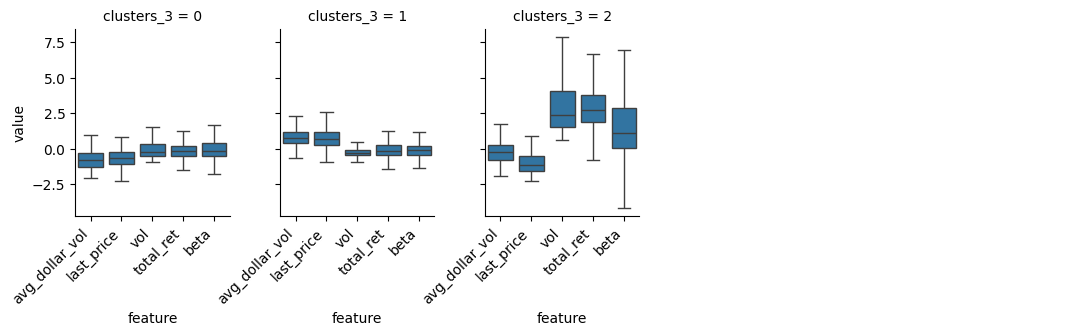

In [330]:
g = sns.catplot(data=transformed_long_3_df, col='clusters_3', y='value', x='feature', col_wrap=5,
            kind='box', height=2.8, aspect=0.75, showfliers=False)
g.set_xticklabels(rotation=45, ha='right')

TODO: show symbols per cluster, requires symbol column in long format dataframe

### So what _is_ the right way to visualize these cluster?
Recall that we used PCA earlier but PCA has its limitations. It is not great for non-linear datasets. TSNE used to be the standard but the current standard is UMAP (unfortunately not part of scikit-learn)

In [351]:
#!pip install umap-learn

Did you notice? You pip install `umap-learn`, not `umap`

In [332]:
import umap

In [337]:
%%time
embeddings = umap.UMAP().fit_transform(clean_df[MODEL_FEATURES])

umap_df = pd.DataFrame(embeddings, columns=['x', 'y'])
umap_df

CPU times: user 5.93 s, sys: 321 ms, total: 6.25 s
Wall time: 3.08 s


,x,y
0,14.273492,11.570068
1,15.575481,11.677944
2,10.899845,24.372143
3,0.722471,20.131264
4,18.703751,5.844421
...,...,...
3093,13.313909,-6.928743
3094,1.489037,10.320095
3095,10.577683,17.673046
3096,-2.976805,-2.759714


<Axes: xlabel='x', ylabel='y'>

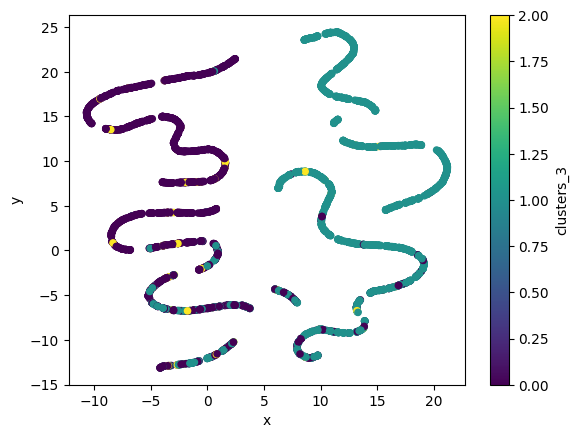

In [350]:
pd.concat([umap_df, transformed_df.clusters_3], axis=1).plot.scatter('x', 'y', c='clusters_3', cmap='viridis')